# Problema 1 – Clasificación: Detección de Fatiga Muscular en Ciclismo
**Workshop 2 – Machine Learning & Deep Learning Aplicado**  
Universidad EAFIT – Introducción a la Inteligencia Artificial (2026-01)

---
**Dataset:** Muscle Fatigue Cycling  
**Fuente:** HuggingFace – [YominE/Muscle_Fatigue_Cycling](https://huggingface.co/datasets/YominE/Muscle_Fatigue_Cycling)

## 0. Instalación y descarga del dataset

In [ ]:
# Instalar dependencias necesarias
!pip install datasets huggingface_hub scikit-learn pandas numpy matplotlib seaborn tensorflow scipy

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np

# Descargar dataset desde HuggingFace
print('Descargando dataset Muscle_Fatigue_Cycling...')
ds = load_dataset('YominE/Muscle_Fatigue_Cycling')
print(ds)

# Convertir a DataFrame
df_raw = pd.DataFrame(ds['train'])
print(f'\nShape del dataset: {df_raw.shape}')
df_raw.head()

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Descargando dataset Muscle_Fatigue_Cycling...


Generating train split: 100%|██████████| 3002137/3002137 [00:17<00:00, 170478.36 examples/s]


DatasetDict({
    train: Dataset({
        features: ['Time', 'Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis', 'Target'],
        num_rows: 3002137
    })
})


Bad pipe message: %s [b'0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7\r\nHost: localhost:38465\r\nUs', b'-Agent: Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.']
Bad pipe message: %s [b'0.0 Safari/537.36\r\nAccept-Encoding: gzip, defla']
Bad pipe message: %s [b', br, zstd\r\nAccept-Language: es-ES,es;q=0.9\r\nCache-Control: max-age=0\r\nReferer: https://didactic-fortnight-9vvjvpx4', b'jf7v5p.github.dev/\r\nX-Request-ID: 2e3b4cb326dcf5b831c']
Bad pipe message: %s [b'79697e528ae\r\nX-Real-IP: 201.232.232.191\r\nX-Forwarded-Po', b': 443\r\nX-Forwarded-Scheme: https\r\nX-Original-URI: /\r\nX-Scheme: https\r\nsec-fetch-site: same-site\r\nsec-fetch-mode: ']
Bad pipe message: %s [b'vigate\r\nsec-fetch-dest: document\r\nsec-ch-ua: "Chromium";v="146", "Not-A.Brand";v="24", "Google Chrome";v="146', b'\nsec-ch-ua-mobile: ?0\r\nsec-ch-ua-', b'atform: "Windows"\r\npriority: u=0, i\r\nX-Forwarded-Proto: https\r\nX-


Shape del dataset: (3002137, 10)


,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
0,0.000,-0.000264,-0.000015,0.000344,0.000108,0.000182,0.000401,0.000267,-0.000236,0
1,0.001,-0.001002,-0.000045,0.001342,0.000429,0.000712,0.002234,0.001234,-0.001108,0
2,0.002,-0.002173,-0.000034,0.002944,0.001133,0.001692,0.007634,0.003457,-0.003277,0
3,0.003,-0.002676,0.000185,0.003504,0.002319,0.002820,0.017656,0.006587,-0.006940,0
4,0.004,-0.000844,0.000785,0.000426,0.003950,0.003729,0.028542,0.008889,-0.011310,0


## 1. Análisis Preliminar del Problema

### 1a. Preprocesamiento del Target

El dataset original puede contener más de 2 etiquetas. Según las instrucciones del workshop, debemos consolidar en:
- `0` = Condición normal
- `1` = Desgaste muscular (las etiquetas estimadas en 2 se cambian por 1)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identificar columna target
print('Columnas del dataset:')
print(df_raw.columns.tolist())
print(f'\nTipos de datos:')
print(df_raw.dtypes)
print(f'\nEstadísticos básicos:')
df_raw.describe()

Columnas del dataset:
['Time', 'Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis', 'Target']

Tipos de datos:
Time                                float64
Right Rectus femoris                float64
Left Gluteus maximus                float64
Left Gastrocnemius medialis         float64
Left Semitendinosus                 float64
Left Biceps femoris caput longus    float64
Right Vastus medialis               float64
Right Tibialis anterior             float64
Left Gastrocnemius lateralis        float64
Target                                int64
dtype: object

Estadísticos básicos:


,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
count,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06
mean,6.385404e+02,3.818719e-10,-5.484116e-09,1.607046e-08,6.232624e-09,2.408926e-08,-2.482363e-08,4.634169e-10,-5.008274e-08,3.723594e-01
std,4.855156e+02,4.322670e-02,2.126250e-02,4.680434e-02,3.235313e-02,4.256358e-02,7.176269e-02,5.702359e-02,5.926507e-02,6.291401e-01
min,0.000000e+00,-8.433421e-01,-1.117295e+00,-1.749318e+00,-1.575973e+00,-7.503011e-01,-1.216622e+00,-1.304432e+00,-1.199719e+00,0.000000e+00
25%,2.501780e+02,-9.712520e-03,-3.884910e-03,-8.921014e-03,-6.285701e-03,-8.235582e-03,-9.509088e-03,-1.332585e-02,-1.391587e-02,0.000000e+00
50%,5.003560e+02,4.047832e-05,-1.482451e-05,9.786492e-05,-1.267264e-04,1.626615e-04,1.187206e-04,-1.495369e-04,6.502335e-04,0.000000e+00
75%,9.910640e+02,1.018903e-02,3.919922e-03,9.312195e-03,6.089190e-03,9.009457e-03,1.112872e-02,1.315710e-02,1.687481e-02,1.000000e+00
max,1.741598e+03,9.920845e-01,1.063230e+00,1.614778e+00,8.685851e-01,8.429890e-01,1.079527e+00,1.336625e+00,9.400506e-01,2.000000e+00


In [3]:
# Inspeccionar columna target (ajustar 'label' o 'target' según el dataset real)
# Primero identificamos cuál es la columna target
possible_targets = [c for c in df_raw.columns if any(k in c.lower() for k in ['label', 'target', 'fatigue', 'condition', 'class'])]
print('Posibles columnas target:', possible_targets)

# --- AJUSTAR ESTA VARIABLE según lo que imprima la celda anterior ---
TARGET_COL = possible_targets[0] if possible_targets else df_raw.columns[-1]
print(f'\nColumna target seleccionada: {TARGET_COL}')
print(f'\nValores únicos en target:')
print(df_raw[TARGET_COL].value_counts())

Posibles columnas target: ['Target']

Columna target seleccionada: Target

Valores únicos en target:
Target
0    2127600
1     631200
2     243337
Name: count, dtype: int64


Distribución del target binarizado:
target
0    2127600
1     874537
Name: count, dtype: int64

  0 = Condición normal: 2127600 muestras
  1 = Desgaste muscular: 874537 muestras


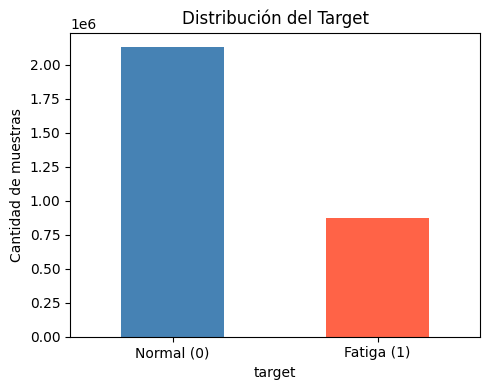

In [4]:
# Preprocesar target: binarizar (etiquetas >= 2 se mapean a 1)
df = df_raw.copy()

# Mapeo: 0 -> 0 (normal), cualquier valor >= 1 -> 1 (desgaste)
# Las etiquetas estimadas en 2 se cambian por 1
df['target'] = df[TARGET_COL].apply(lambda x: 0 if x == 0 else 1)

print('Distribución del target binarizado:')
print(df['target'].value_counts())
print(f'\n  0 = Condición normal: {(df["target"]==0).sum()} muestras')
print(f'  1 = Desgaste muscular: {(df["target"]==1).sum()} muestras')

fig, ax = plt.subplots(figsize=(5, 4))
df['target'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Distribución del Target')
ax.set_xticklabels(['Normal (0)', 'Fatiga (1)'], rotation=0)
ax.set_ylabel('Cantidad de muestras')
plt.tight_layout()
plt.show()

### 1b. Clasificación de variables

Se identifican los tipos de variables presentes en el dataset.

In [5]:
# Identificar columnas de señal EMG (los 8 canales musculares)
# y la columna de tiempo
print('Primeras filas del dataset:')
print(df_raw.head(3))

# Identificar columna de tiempo
time_cols = [c for c in df_raw.columns if 'time' in c.lower() or 'timestamp' in c.lower()]
print(f'\nColumnas de tiempo: {time_cols}')

# Identificar columnas de señal EMG (numéricas, excluyendo tiempo y target)
exclude = time_cols + [TARGET_COL]
EMG_COLS = [c for c in df_raw.columns if c not in exclude and df_raw[c].dtype in [np.float64, np.int64, float, int]]
print(f'\nCanales EMG identificados ({len(EMG_COLS)}): {EMG_COLS}')

# Ajustar si hay columna de tiempo
TIME_COL = time_cols[0] if time_cols else None

print(f'\n--- Clasificación de variables ---')
print(f'  Tiempo ({TIME_COL}): Numérica continua (será excluida del modelado)')
print(f'  Señales EMG ({len(EMG_COLS)} canales): Numéricas continuas (variables independientes)')
print(f'  Target (binarizado): Binaria [0=Normal, 1=Fatiga] (variable dependiente)')

Primeras filas del dataset:
    Time  Right Rectus femoris  Left Gluteus maximus  \
0  0.000             -0.000264             -0.000015   
1  0.001             -0.001002             -0.000045   
2  0.002             -0.002173             -0.000034   

   Left Gastrocnemius medialis  Left Semitendinosus  \
0                     0.000344             0.000108   
1                     0.001342             0.000429   
2                     0.002944             0.001133   

   Left Biceps femoris caput longus  Right Vastus medialis  \
0                          0.000182               0.000401   
1                          0.000712               0.002234   
2                          0.001692               0.007634   

   Right Tibialis anterior  Left Gastrocnemius lateralis  Target  
0                 0.000267                     -0.000236       0  
1                 0.001234                     -0.001108       0  
2                 0.003457                     -0.003277       0  

Columnas

## 2. Extracción de Características (Feature Engineering)

### 2a. Determinación de la frecuencia de muestreo

In [6]:
# Determinar frecuencia de muestreo a partir de la columna de tiempo
if TIME_COL:
    time_diff = df[TIME_COL].diff().dropna()
    dt_mean = time_diff.mean()  # Período de muestreo promedio
    fs = 1.0 / dt_mean
    print(f'Período de muestreo promedio: {dt_mean:.6f} s')
    print(f'Frecuencia de muestreo estimada: {fs:.2f} Hz')
else:
    # Si no hay columna de tiempo, asumir frecuencia típica de EMG
    fs = 1000.0  # Hz (valor típico para EMG en ciclismo)
    print(f'Columna de tiempo no encontrada. Asumiendo fs = {fs} Hz (típico para señales EMG)')

WINDOW_SIZE = int(fs)  # 1 segundo de datos
print(f'\nTamaño de ventana (1 segundo): {WINDOW_SIZE} muestras')

Período de muestreo promedio: 0.000191 s
Frecuencia de muestreo estimada: 5230.09 Hz

Tamaño de ventana (1 segundo): 5230 muestras


### 2b & 2c. Extracción de características por ventana

Se extraen **6 características por canal** (3 en dominio del tiempo + 3 en dominio de la frecuencia):

**Dominio del tiempo:**
- **RMS (Root Mean Square):** Mide la amplitud general de la señal EMG. A medida que el músculo se fatiga, el RMS tiende a aumentar debido al reclutamiento de más unidades motoras.
- **Varianza:** Captura la dispersión de la señal. La fatiga aumenta la variabilidad de la activación muscular.
- **Zero Crossing Rate (ZCR):** Número de veces que la señal cruza cero. Con la fatiga, la frecuencia de cruce tiende a disminuir.
- **Mean Absolute Value (MAV):** Promedio del valor absoluto. Indicador robusto de la activación muscular.

**Dominio de la frecuencia:**
- **Frecuencia Mediana:** La frecuencia a la que el espectro de potencia se divide en dos mitades iguales. Con la fatiga, la frecuencia mediana tiende a disminuir (fatigue shift).
- **Frecuencia Media:** Centro de masa del espectro. También decrece con la fatiga, confirmando el fatigue shift.
- **Potencia Total:** Energía total de la señal en el espectro. Refleja el nivel de activación global del músculo.

In [7]:
from scipy import signal as scipy_signal

def extract_features_window(window, fs):
    """Extrae características de dominio tiempo y frecuencia de una ventana EMG."""
    features = {}
    
    # --- DOMINIO DEL TIEMPO ---
    # 1. RMS: amplitud efectiva de la señal
    features['rms'] = np.sqrt(np.mean(window**2))
    
    # 2. Varianza: dispersión de la señal
    features['variance'] = np.var(window)
    
    # 3. Zero Crossing Rate: tasa de cruces por cero
    zc = np.sum(np.diff(np.sign(window)) != 0)
    features['zcr'] = zc / len(window)
    
    # 4. Mean Absolute Value: activación media
    features['mav'] = np.mean(np.abs(window))
    
    # --- DOMINIO DE LA FRECUENCIA ---
    freqs, psd = scipy_signal.welch(window, fs=fs, nperseg=min(256, len(window)))
    
    # 5. Frecuencia Mediana (MNF)
    cumulative_power = np.cumsum(psd)
    total_power = cumulative_power[-1]
    median_freq_idx = np.searchsorted(cumulative_power, total_power / 2)
    features['median_freq'] = freqs[min(median_freq_idx, len(freqs)-1)]
    
    # 6. Frecuencia Media (MDF)
    features['mean_freq'] = np.sum(freqs * psd) / np.sum(psd) if np.sum(psd) > 0 else 0
    
    # 7. Potencia Total Espectral
    features['total_power'] = np.sum(psd)
    
    return features


def build_feature_dataset(df, emg_cols, target_col, window_size, fs):
    """Construye dataset de características por ventanas deslizantes (sin solapamiento)."""
    n_samples = len(df)
    all_features = []
    all_targets = []
    
    for start in range(0, n_samples - window_size + 1, window_size):
        end = start + window_size
        window_df = df.iloc[start:end]
        
        row_features = {}
        for ch in emg_cols:
            window_signal = window_df[ch].values.astype(float)
            ch_feats = extract_features_window(window_signal, fs)
            for feat_name, feat_val in ch_feats.items():
                row_features[f'{ch}_{feat_name}'] = feat_val
        
        all_features.append(row_features)
        # Etiqueta de la ventana: moda del target en esa ventana
        window_target = window_df[target_col].mode()[0]
        all_targets.append(window_target)
    
    feat_df = pd.DataFrame(all_features)
    feat_df['target'] = all_targets
    return feat_df


print('Extrayendo características...')
feat_df = build_feature_dataset(df, EMG_COLS, 'target', WINDOW_SIZE, fs)
print(f'Dataset de características generado: {feat_df.shape}')
print(f'  Ventanas totales: {len(feat_df)}')
print(f'  Características por ventana: {feat_df.shape[1] - 1}')
feat_df.head()

Extrayendo características...
Dataset de características generado: (574, 57)
  Ventanas totales: 574
  Características por ventana: 56


,Right Rectus femoris_rms,Right Rectus femoris_variance,Right Rectus femoris_zcr,Right Rectus femoris_mav,Right Rectus femoris_median_freq,Right Rectus femoris_mean_freq,Right Rectus femoris_total_power,Left Gluteus maximus_rms,Left Gluteus maximus_variance,Left Gluteus maximus_zcr,...,Right Tibialis anterior_mean_freq,Right Tibialis anterior_total_power,Left Gastrocnemius lateralis_rms,Left Gastrocnemius lateralis_variance,Left Gastrocnemius lateralis_zcr,Left Gastrocnemius lateralis_mav,Left Gastrocnemius lateralis_median_freq,Left Gastrocnemius lateralis_mean_freq,Left Gastrocnemius lateralis_total_power,target
0,0.013768,0.000190,0.119694,0.009774,265.590647,294.806849,0.000009,0.004311,0.000019,0.120268,...,480.628545,0.000030,0.025786,0.000665,0.129637,0.018966,306.450747,341.820320,0.000033,0
1,0.012707,0.000161,0.118929,0.008670,265.590647,297.296423,0.000008,0.004450,0.000020,0.128872,...,468.059966,0.000026,0.026802,0.000718,0.131166,0.019509,367.740897,363.308832,0.000035,0
2,0.013751,0.000189,0.118547,0.009440,286.020697,306.823344,0.000009,0.004441,0.000020,0.120459,...,451.009035,0.000023,0.028518,0.000813,0.133078,0.021284,347.310847,358.837329,0.000041,0
3,0.013795,0.000190,0.122371,0.009645,286.020697,312.935537,0.000010,0.004450,0.000020,0.124665,...,463.408960,0.000024,0.028344,0.000803,0.118738,0.020265,367.740897,370.920070,0.000041,0
4,0.013301,0.000177,0.122371,0.009474,265.590647,297.492592,0.000009,0.004411,0.000019,0.125048,...,472.371490,0.000031,0.024893,0.000620,0.133652,0.017800,388.170946,384.496729,0.000031,0


## 3. Análisis Exploratorio de Datos (EDA)

### 3a. Visualización de señales en el tiempo

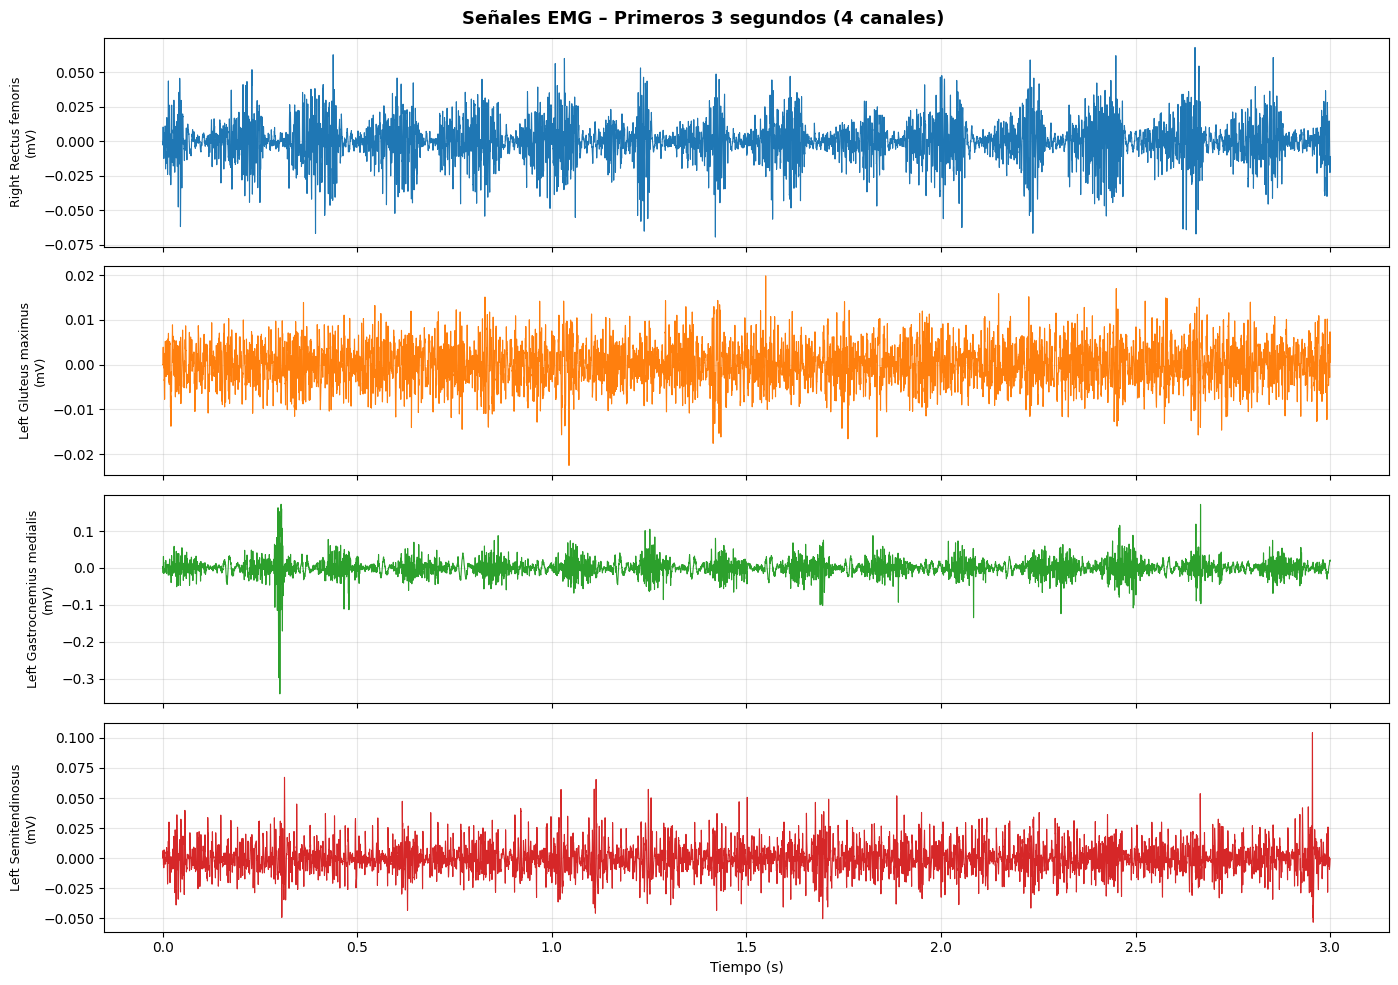


INTERPRETACIÓN:
Las señales EMG presentan el patrón típico de electromiografía: oscilaciones de alta frecuencia
con amplitud variable. Se puede observar activación muscular intermitente correspondiente a los
sprints en bicicleta. La variación en amplitud entre canales refleja diferencias en el nivel de
activación de cada músculo (ej. cuádriceps vs. isquiotibiales). La señal no muestra artefactos
evidentes en este segmento inicial, lo que sugiere una buena calidad de adquisición.



In [8]:
# Graficar primeros 3 segundos de los primeros 4 canales EMG
n_plot = min(int(3 * fs), len(df))  # 3 segundos
time_axis = np.arange(n_plot) / fs

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
channels_to_plot = EMG_COLS[:4]

for i, ch in enumerate(channels_to_plot):
    axes[i].plot(time_axis, df[ch].values[:n_plot], linewidth=0.8, color=f'C{i}')
    axes[i].set_ylabel(f'{ch}\n(mV)', fontsize=9)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Tiempo (s)')
fig.suptitle('Señales EMG – Primeros 3 segundos (4 canales)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
INTERPRETACIÓN:
Las señales EMG presentan el patrón típico de electromiografía: oscilaciones de alta frecuencia
con amplitud variable. Se puede observar activación muscular intermitente correspondiente a los
sprints en bicicleta. La variación en amplitud entre canales refleja diferencias en el nivel de
activación de cada músculo (ej. cuádriceps vs. isquiotibiales). La señal no muestra artefactos
evidentes en este segmento inicial, lo que sugiere una buena calidad de adquisición.
""")

### 3b. Estadísticos descriptivos

In [9]:
X_feat = feat_df.drop(columns=['target'])
y_feat = feat_df['target']

print('Estadísticos descriptivos del dataset de características:')
display(X_feat.describe().T.round(4))

Estadísticos descriptivos del dataset de características:


,count,mean,std,min,25%,50%,75%,max
Right Rectus femoris_rms,574.0,0.0368,0.0227,0.0032,0.0245,0.0315,0.0419,0.1616
Right Rectus femoris_variance,574.0,0.0019,0.0033,0.0000,0.0006,0.0010,0.0018,0.0261
Right Rectus femoris_zcr,574.0,0.1090,0.0092,0.0849,0.1023,0.1077,0.1145,0.1358
Right Rectus femoris_mav,574.0,0.0226,0.0135,0.0023,0.0152,0.0190,0.0260,0.1029
Right Rectus femoris_median_freq,574.0,246.8334,29.5795,122.5803,224.7305,245.1606,265.5906,326.8808
Right Rectus femoris_mean_freq,574.0,282.0121,23.2742,184.5997,271.7148,283.7309,297.1140,339.2807
Right Rectus femoris_total_power,574.0,0.0001,0.0002,0.0000,0.0000,0.0000,0.0001,0.0013
Left Gluteus maximus_rms,574.0,0.0123,0.0173,0.0035,0.0059,0.0077,0.0111,0.1727
Left Gluteus maximus_variance,574.0,0.0005,0.0022,0.0000,0.0000,0.0001,0.0001,0.0298
Left Gluteus maximus_zcr,574.0,0.1204,0.0148,0.0539,0.1137,0.1229,0.1300,0.1558


### 3c. Distribuciones de características

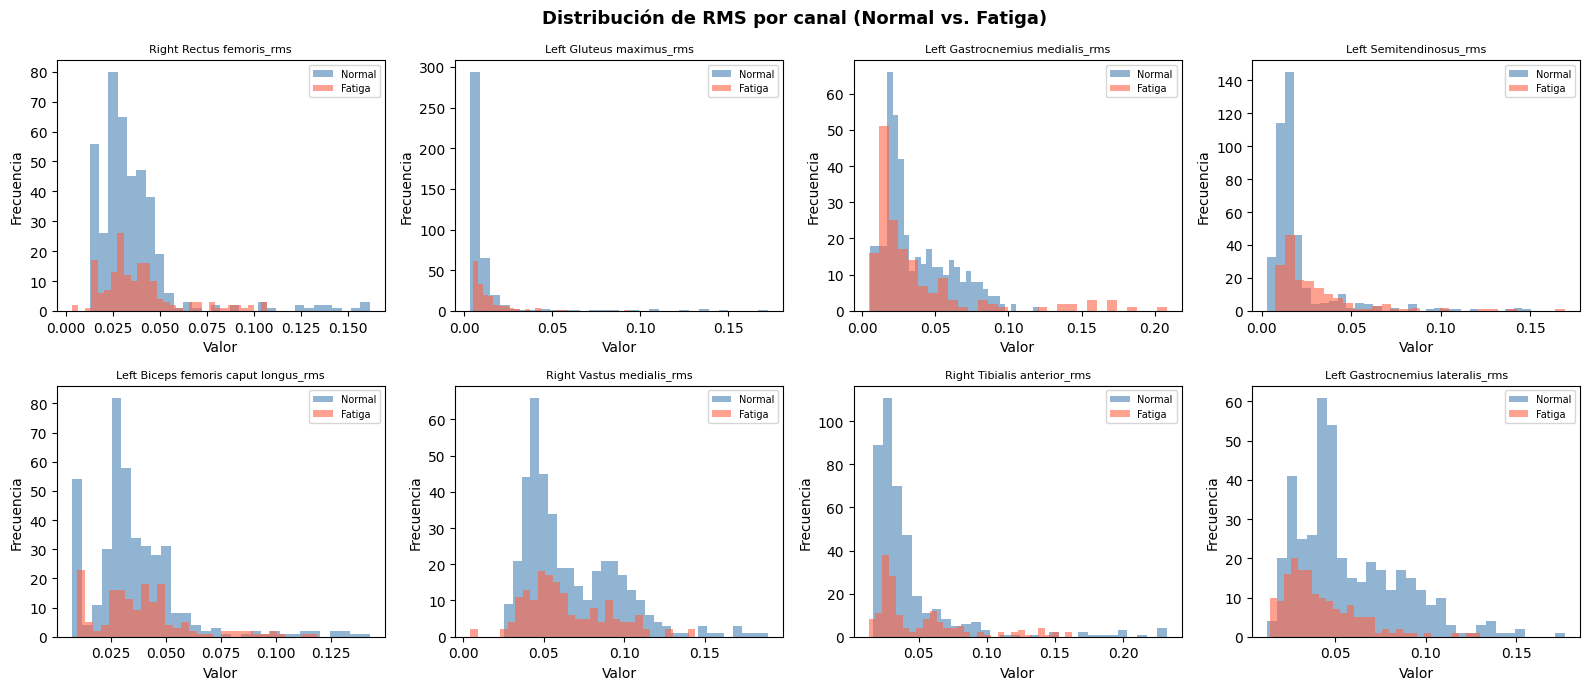


INTERPRETACIÓN:
Se puede observar cómo los valores de RMS difieren entre condición normal y fatiga en varios canales.
En músculos primarios (ej. cuádriceps), el RMS tiende a ser mayor en condición de fatiga debido al
reclutamiento de unidades motoras adicionales para mantener la fuerza requerida. Esta separabilidad
visual indica que el RMS es una característica discriminante para el problema de clasificación.



In [10]:
# Seleccionar características representativas (RMS de cada canal) para visualizar
rms_cols = [c for c in X_feat.columns if 'rms' in c]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(rms_cols[:8]):
    axes[i].hist(feat_df[feat_df['target']==0][col], bins=30, alpha=0.6, label='Normal', color='steelblue')
    axes[i].hist(feat_df[feat_df['target']==1][col], bins=30, alpha=0.6, label='Fatiga', color='tomato')
    axes[i].set_title(f'{col}', fontsize=8)
    axes[i].legend(fontsize=7)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de RMS por canal (Normal vs. Fatiga)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
INTERPRETACIÓN:
Se puede observar cómo los valores de RMS difieren entre condición normal y fatiga en varios canales.
En músculos primarios (ej. cuádriceps), el RMS tiende a ser mayor en condición de fatiga debido al
reclutamiento de unidades motoras adicionales para mantener la fuerza requerida. Esta separabilidad
visual indica que el RMS es una característica discriminante para el problema de clasificación.
""")

### 3d. Mapa de correlaciones

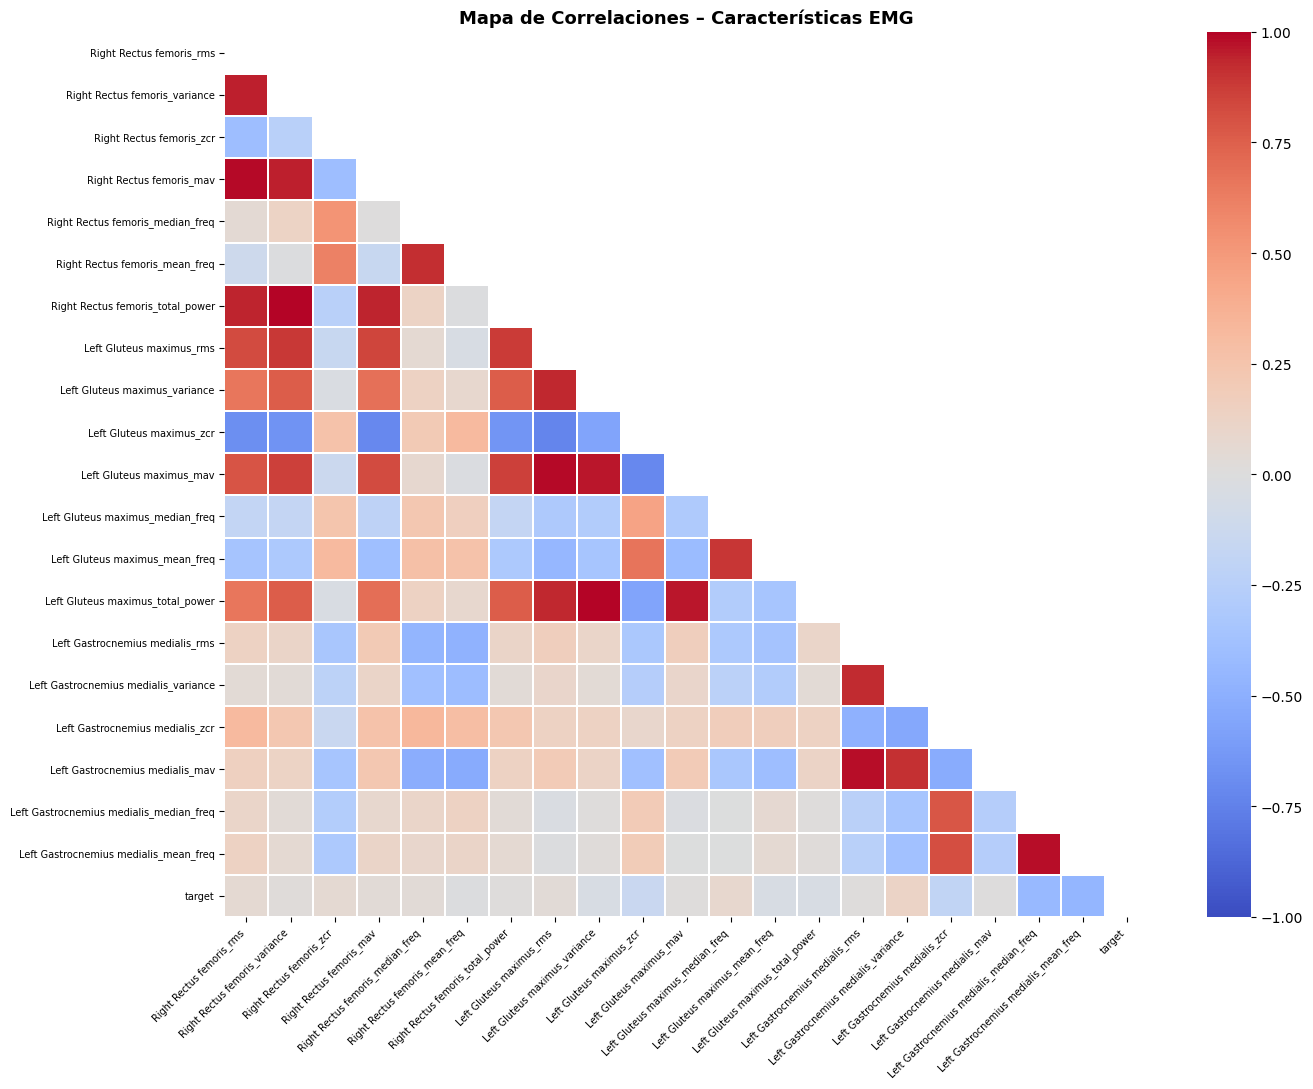

Top 10 características más correlacionadas con el target:
Left Gastrocnemius medialis_mean_freq      0.456280
Left Gastrocnemius medialis_median_freq    0.436558
Right Vastus medialis_mean_freq            0.299711
Right Vastus medialis_median_freq          0.278333
Left Semitendinosus_median_freq            0.276899
Left Semitendinosus_mean_freq              0.260854
Left Gastrocnemius lateralis_rms           0.248064
Right Tibialis anterior_zcr                0.237724
Right Tibialis anterior_mean_freq          0.235404
Left Gastrocnemius lateralis_mav           0.233431
Name: target, dtype: float64

INTERPRETACIÓN:
Las características del mismo tipo (ej. RMS de diferentes canales) muestran alta correlación entre sí,
lo que es esperado ya que músculos sinergistas se activan juntos. La correlación con el target revela
qué características tienen mayor poder discriminativo. Las frecuencias mediana y media suelen mostrar
alta correlación con la fatiga muscular (fatigue shift espectral).



In [11]:
# Correlación entre características (muestra un subconjunto si hay muchas)
sample_cols = X_feat.columns[:min(20, len(X_feat.columns))]
corr_matrix = feat_df[list(sample_cols) + ['target']].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, vmin=-1, vmax=1)
plt.title('Mapa de Correlaciones – Características EMG', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# Correlación con target
corr_with_target = feat_df.corr()['target'].drop('target').abs().sort_values(ascending=False)
print('Top 10 características más correlacionadas con el target:')
print(corr_with_target.head(10))

print("""
INTERPRETACIÓN:
Las características del mismo tipo (ej. RMS de diferentes canales) muestran alta correlación entre sí,
lo que es esperado ya que músculos sinergistas se activan juntos. La correlación con el target revela
qué características tienen mayor poder discriminativo. Las frecuencias mediana y media suelen mostrar
alta correlación con la fatiga muscular (fatigue shift espectral).
""")

### 3e. Boxplots por clase y balance de clases

/tmp/ipykernel_11591/458968406.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_normal, data_fatiga], labels=['Normal (0)', 'Fatiga (1)'],
/tmp/ipykernel_11591/458968406.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_normal, data_fatiga], labels=['Normal (0)', 'Fatiga (1)'],
/tmp/ipykernel_11591/458968406.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_normal, data_fatiga], labels=['Normal (0)', 'Fatiga (1)'],
/tmp/ipykernel_11591/458968406.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_lab

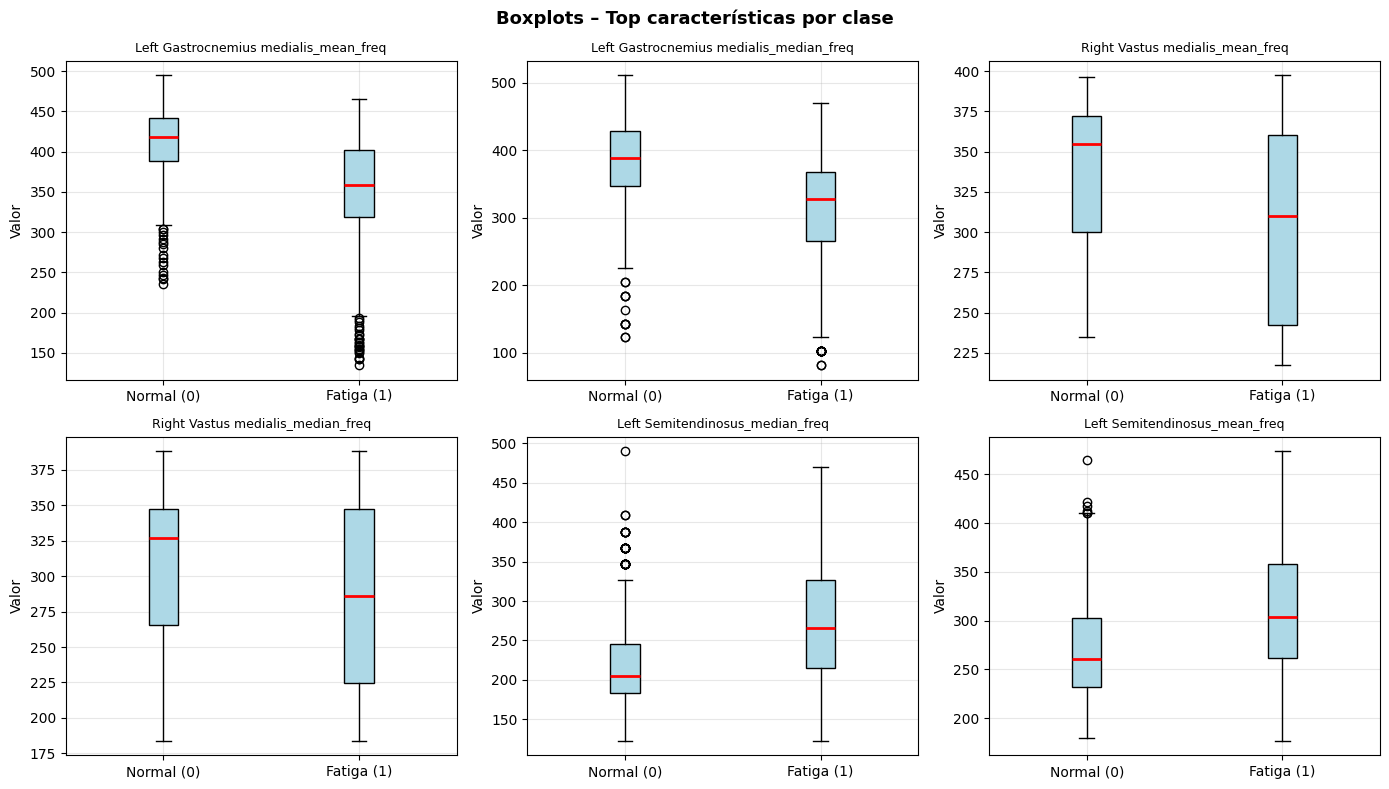

Balance de clases en el dataset de características:
target
0    407
1    167
Name: count, dtype: int64

Ratio Normal/Fatiga: 2.44

INTERPRETACIÓN:
Los boxplots muestran la separabilidad entre clases para las características más informativas.
Una diferencia clara en la mediana y distribución entre Normal y Fatiga indica mayor poder predictivo.
Características como median_freq muestran el 'fatigue shift': durante la fatiga, la frecuencia
mediana del espectro EMG decrece, un fenómeno fisiológico bien documentado.



In [12]:
# Boxplots de características más discriminativas por clase
top_feats = corr_with_target.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(top_feats):
    data_normal = feat_df[feat_df['target']==0][feat]
    data_fatiga = feat_df[feat_df['target']==1][feat]
    axes[i].boxplot([data_normal, data_fatiga], labels=['Normal (0)', 'Fatiga (1)'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_ylabel('Valor')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Boxplots – Top características por clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Balance de clases
print('Balance de clases en el dataset de características:')
print(y_feat.value_counts())
print(f'\nRatio Normal/Fatiga: {y_feat.value_counts()[0]/y_feat.value_counts()[1]:.2f}')

print("""
INTERPRETACIÓN:
Los boxplots muestran la separabilidad entre clases para las características más informativas.
Una diferencia clara en la mediana y distribución entre Normal y Fatiga indica mayor poder predictivo.
Características como median_freq muestran el 'fatigue shift': durante la fatiga, la frecuencia
mediana del espectro EMG decrece, un fenómeno fisiológico bien documentado.
""")

## 4. Procesamiento de Datos

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Verificar valores nulos
null_counts = feat_df.isnull().sum()
print('Valores nulos por columna (solo columnas con nulos):')
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else 'No hay valores nulos.')

# Verificar infinitos
inf_counts = np.isinf(feat_df.select_dtypes(include=np.number)).sum().sum()
print(f'Valores infinitos: {inf_counts}')

# Reemplazar infinitos si los hay
feat_df.replace([np.inf, -np.inf], np.nan, inplace=True)

Valores nulos por columna (solo columnas con nulos):
No hay valores nulos.
Valores infinitos: 0


,Right Rectus femoris_rms,Right Rectus femoris_variance,Right Rectus femoris_zcr,Right Rectus femoris_mav,Right Rectus femoris_median_freq,Right Rectus femoris_mean_freq,Right Rectus femoris_total_power,Left Gluteus maximus_rms,Left Gluteus maximus_variance,Left Gluteus maximus_zcr,...,Right Tibialis anterior_mean_freq,Right Tibialis anterior_total_power,Left Gastrocnemius lateralis_rms,Left Gastrocnemius lateralis_variance,Left Gastrocnemius lateralis_zcr,Left Gastrocnemius lateralis_mav,Left Gastrocnemius lateralis_median_freq,Left Gastrocnemius lateralis_mean_freq,Left Gastrocnemius lateralis_total_power,target
0,0.013768,0.000190,0.119694,0.009774,265.590647,294.806849,0.000009,0.004311,0.000019,0.120268,...,480.628545,0.000030,0.025786,0.000665,0.129637,0.018966,306.450747,341.820320,0.000033,0
1,0.012707,0.000161,0.118929,0.008670,265.590647,297.296423,0.000008,0.004450,0.000020,0.128872,...,468.059966,0.000026,0.026802,0.000718,0.131166,0.019509,367.740897,363.308832,0.000035,0
2,0.013751,0.000189,0.118547,0.009440,286.020697,306.823344,0.000009,0.004441,0.000020,0.120459,...,451.009035,0.000023,0.028518,0.000813,0.133078,0.021284,347.310847,358.837329,0.000041,0
3,0.013795,0.000190,0.122371,0.009645,286.020697,312.935537,0.000010,0.004450,0.000020,0.124665,...,463.408960,0.000024,0.028344,0.000803,0.118738,0.020265,367.740897,370.920070,0.000041,0
4,0.013301,0.000177,0.122371,0.009474,265.590647,297.492592,0.000009,0.004411,0.000019,0.125048,...,472.371490,0.000031,0.024893,0.000620,0.133652,0.017800,388.170946,384.496729,0.000031,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569,0.045316,0.002054,0.107075,0.027520,245.160598,267.478446,0.000091,0.011680,0.000136,0.113576,...,222.003344,0.000192,0.029012,0.000842,0.166922,0.016432,429.031046,450.168863,0.000038,1
570,0.068350,0.004672,0.105354,0.045424,224.730548,261.636615,0.000225,0.022775,0.000519,0.113193,...,223.892534,0.000712,0.056758,0.003222,0.172467,0.037639,408.600996,454.501356,0.000167,1
571,0.041982,0.001762,0.110325,0.022631,224.730548,255.644259,0.000070,0.012187,0.000149,0.140727,...,242.931049,0.000147,0.041554,0.001727,0.169981,0.025250,429.031046,451.849980,0.000074,1
572,0.043932,0.001930,0.108604,0.023656,204.300498,247.125072,0.000088,0.015041,0.000226,0.126577,...,240.979375,0.000251,0.034941,0.001221,0.169407,0.019897,449.461096,461.179014,0.000052,1


In [14]:
# Separar features y target
X = feat_df.drop(columns=['target']).values
y = feat_df['target'].values
feature_names = feat_df.drop(columns=['target']).columns.tolist()

# División 70% train / 15% val / 15% test
# Justificación: 70% asegura suficientes datos para entrenamiento;
# 15% val permite ajuste de hiperparámetros; 15% test para evaluación imparcial final.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85, random_state=42, stratify=y_trainval)

print(f'Tamaños de los conjuntos:')
print(f'  X_train: {X_train.shape} ({len(X_train)/len(X)*100:.1f}%)')
print(f'  X_val:   {X_val.shape} ({len(X_val)/len(X)*100:.1f}%)')
print(f'  X_test:  {X_test.shape} ({len(X_test)/len(X)*100:.1f}%)')

# Pipeline de preprocesamiento
preprocessing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Manejo de nulos con mediana
    ('scaler', StandardScaler())                     # Estandarización (media 0, std 1)
])

# Fit solo en train para evitar data leakage
X_train_proc = preprocessing_pipeline.fit_transform(X_train)
X_val_proc   = preprocessing_pipeline.transform(X_val)
X_test_proc  = preprocessing_pipeline.transform(X_test)

print('\nPipeline de preprocesamiento aplicado exitosamente.')
print(f'  Imputer: mediana (robusto a outliers)')
print(f'  Scaler: StandardScaler (necesario para kNN y DNN)')

Tamaños de los conjuntos:
  X_train: (401, 56) (69.9%)
  X_val:   (86, 56) (15.0%)
  X_test:  (87, 56) (15.2%)

Pipeline de preprocesamiento aplicado exitosamente.
  Imputer: mediana (robusto a outliers)
  Scaler: StandardScaler (necesario para kNN y DNN)


## 5. Entrenamiento y Comparación de Modelos

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

def evaluate_model(model, X_tr, y_tr, X_v, y_v, X_te, y_te):
    """Evalúa un modelo en train, val y test. Devuelve dict de métricas."""
    results = {}
    for split_name, X_s, y_s in [('Train', X_tr, y_tr), ('Val', X_v, y_v), ('Test', X_te, y_te)]:
        preds = model.predict(X_s)
        results[split_name] = {
            'Accuracy':  accuracy_score(y_s, preds),
            'Precision': precision_score(y_s, preds, zero_division=0),
            'Recall':    recall_score(y_s, preds, zero_division=0),
            'F1-Score':  f1_score(y_s, preds, zero_division=0),
        }
    return results

all_results = {}

### 5a-b. k-Nearest Neighbors (kNN)

In [16]:
print('Ajustando hiperparámetros de kNN con RandomSearchCV...')

knn_params = {
    'n_neighbors': list(range(3, 21, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_search = RandomizedSearchCV(
    KNeighborsClassifier(), knn_params,
    n_iter=20, cv=5, scoring='f1', random_state=42, n_jobs=-1
)
knn_search.fit(X_train_proc, y_train)
knn_best = knn_search.best_estimator_

print(f'Mejores hiperparámetros kNN: {knn_search.best_params_}')
all_results['kNN'] = evaluate_model(knn_best, X_train_proc, y_train, X_val_proc, y_val, X_test_proc, y_test)
print('kNN entrenado.')

Ajustando hiperparámetros de kNN con RandomSearchCV...
Mejores hiperparámetros kNN: {'weights': 'distance', 'n_neighbors': 3, 'metric': 'manhattan'}
kNN entrenado.


### 5a-b. Decision Tree

In [17]:
print('Ajustando hiperparámetros de Decision Tree...')

dt_params = {
    'max_depth': [3, 5, 8, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42), dt_params,
    n_iter=20, cv=5, scoring='f1', random_state=42, n_jobs=-1
)
dt_search.fit(X_train_proc, y_train)
dt_best = dt_search.best_estimator_

print(f'Mejores hiperparámetros DT: {dt_search.best_params_}')
all_results['Decision Tree'] = evaluate_model(dt_best, X_train_proc, y_train, X_val_proc, y_val, X_test_proc, y_test)
print('Decision Tree entrenado.')

Ajustando hiperparámetros de Decision Tree...
Mejores hiperparámetros DT: {'min_samples_split': 5, 'min_samples_leaf': 10, 'max_depth': 8, 'criterion': 'gini'}
Decision Tree entrenado.


### 5a-b. Random Forest

In [18]:
print('Ajustando hiperparámetros de Random Forest...')

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), rf_params,
    n_iter=20, cv=5, scoring='f1', random_state=42, n_jobs=-1
)
rf_search.fit(X_train_proc, y_train)
rf_best = rf_search.best_estimator_

print(f'Mejores hiperparámetros RF: {rf_search.best_params_}')
all_results['Random Forest'] = evaluate_model(rf_best, X_train_proc, y_train, X_val_proc, y_val, X_test_proc, y_test)
print('Random Forest entrenado.')

Ajustando hiperparámetros de Random Forest...
Mejores hiperparámetros RF: {'n_estimators': 100, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': 15}
Random Forest entrenado.


### 5a-b. Gradient Boosting

In [19]:
print('Ajustando hiperparámetros de Gradient Boosting...')

gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42), gb_params,
    n_iter=20, cv=5, scoring='f1', random_state=42, n_jobs=-1
)
gb_search.fit(X_train_proc, y_train)
gb_best = gb_search.best_estimator_

print(f'Mejores hiperparámetros GB: {gb_search.best_params_}')
all_results['Gradient Boosting'] = evaluate_model(gb_best, X_train_proc, y_train, X_val_proc, y_val, X_test_proc, y_test)
print('Gradient Boosting entrenado.')

Ajustando hiperparámetros de Gradient Boosting...
Mejores hiperparámetros GB: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2}
Gradient Boosting entrenado.


### 5a-b. Deep Neural Network (DNN)

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

n_features = X_train_proc.shape[1]

def build_dnn(n_features, learning_rate=0.001, dropout_rate=0.3):
    """DNN con 4 capas ocultas, Batch Normalization y Dropout."""
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        
        # Capa oculta 1
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        
        # Capa oculta 2
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        
        # Capa oculta 3
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        
        # Capa oculta 4
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout_rate / 2),
        
        # Salida binaria
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

dnn_model = build_dnn(n_features)
dnn_model.summary()

# Callbacks
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)
lr_reducer = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

print('\nEntrenando DNN...')
history = dnn_model.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, lr_reducer],
    verbose=1
)

I0000 00:00:1774483061.747936   11591 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774483063.484751   11591 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774483067.552124   11591 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1774483068.023270   11591 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,649 (233.00 KB)

 Trainable params: 58,753 (229.50 KB)

 Non-trainable params: 896 (3.50 KB)


Entrenando DNN...
Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6209 - loss: 0.7009 - val_accuracy: 0.7558 - val_loss: 0.6133 - learning_rate: 0.0010
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7232 - loss: 0.5209 - val_accuracy: 0.8953 - val_loss: 0.5119 - learning_rate: 0.0010
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8155 - loss: 0.4598 - val_accuracy: 0.9070 - val_loss: 0.4452 - learning_rate: 0.0010
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8354 - loss: 0.3853 - val_accuracy: 0.9186 - val_loss: 0.3957 - learning_rate: 0.0010
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8404 - loss: 0.3880 - val_accuracy: 0.9070 - val_loss: 0.3604 - learning_rate: 0.0010
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8479 - loss: 0.3556 - val_accuracy: 0.9070 - val_loss: 0.3310 - learning_rate: 0.0010
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8554 - l

In [21]:
# Evaluar DNN
dnn_results = {}
for split_name, X_s, y_s in [('Train', X_train_proc, y_train), ('Val', X_val_proc, y_val), ('Test', X_test_proc, y_test)]:
    preds_prob = dnn_model.predict(X_s, verbose=0).flatten()
    preds = (preds_prob >= 0.5).astype(int)
    dnn_results[split_name] = {
        'Accuracy':  accuracy_score(y_s, preds),
        'Precision': precision_score(y_s, preds, zero_division=0),
        'Recall':    recall_score(y_s, preds, zero_division=0),
        'F1-Score':  f1_score(y_s, preds, zero_division=0),
    }

all_results['DNN'] = dnn_results
print('DNN evaluado.')

DNN evaluado.


### 5c. Tabla comparativa de resultados

In [22]:
# Construir tabla comparativa
rows = []
for model_name, splits in all_results.items():
    for split_name, metrics in splits.items():
        row = {'Modelo': model_name, 'Split': split_name}
        row.update(metrics)
        rows.append(row)

results_df = pd.DataFrame(rows)
results_pivot = results_df.pivot_table(index='Modelo', columns='Split',
                                        values=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
results_pivot.columns = [f'{m}_{s}' for m, s in results_pivot.columns]

# Ordenar columnas
ordered_cols = []
for split in ['Train', 'Val', 'Test']:
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
        col = f'{metric}_{split}'
        if col in results_pivot.columns:
            ordered_cols.append(col)

results_pivot = results_pivot[ordered_cols].round(4)
print('=== TABLA COMPARATIVA DE MODELOS ===')
display(results_pivot)

=== TABLA COMPARATIVA DE MODELOS ===


,Accuracy_Train,Precision_Train,Recall_Train,F1-Score_Train,Accuracy_Val,Precision_Val,Recall_Val,F1-Score_Val,Accuracy_Test,Precision_Test,Recall_Test,F1-Score_Test
Modelo,,,,,,,,,,,,
DNN,0.9426,0.9352,0.8632,0.8978,0.9070,0.9048,0.76,0.8261,0.8506,0.8000,0.64,0.7111
Decision Tree,0.9127,0.8727,0.8205,0.8458,0.8372,0.7200,0.72,0.7200,0.7931,0.6522,0.60,0.6250
Gradient Boosting,1.0000,1.0000,1.0000,1.0000,0.9302,0.9130,0.84,0.8750,0.8621,0.7407,0.80,0.7692
Random Forest,1.0000,1.0000,1.0000,1.0000,0.9186,0.9091,0.80,0.8511,0.8966,0.8333,0.80,0.8163
kNN,1.0000,1.0000,1.0000,1.0000,0.8953,0.8333,0.80,0.8163,0.9080,0.8400,0.84,0.8400


### 5d. Curvas de entrenamiento

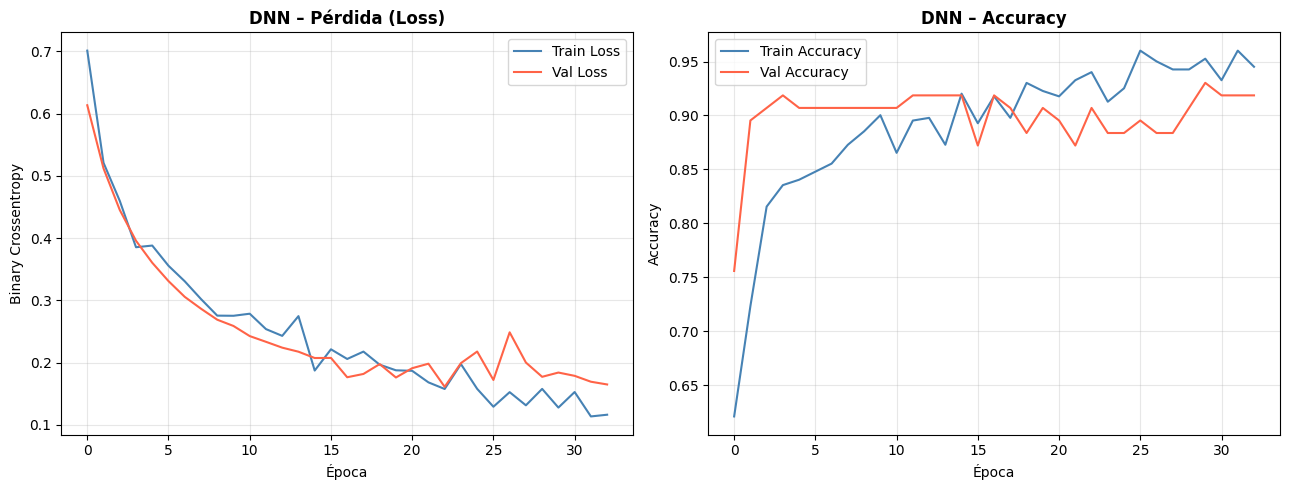

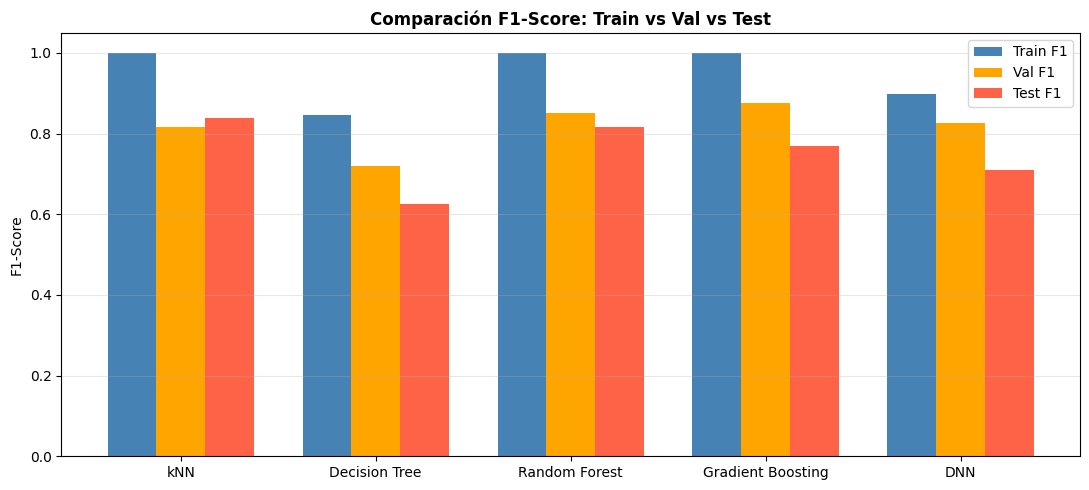

In [23]:
# Curvas de entrenamiento de la DNN
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='tomato')
axes[0].set_title('DNN – Pérdida (Loss)', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='tomato')
axes[1].set_title('DNN – Accuracy', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparación overfitting entre modelos (Train vs Val F1)
model_names = list(all_results.keys())
train_f1 = [all_results[m]['Train']['F1-Score'] for m in model_names]
val_f1   = [all_results[m]['Val']['F1-Score'] for m in model_names]
test_f1  = [all_results[m]['Test']['F1-Score'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, train_f1, width, label='Train F1', color='steelblue')
ax.bar(x, val_f1, width, label='Val F1', color='orange')
ax.bar(x + width, test_f1, width, label='Test F1', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.05)
ax.set_title('Comparación F1-Score: Train vs Val vs Test', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 5e. Análisis de resultados

In [24]:
# Identificar mejor modelo por F1 en validación
best_model_name = max(all_results, key=lambda m: all_results[m]['Val']['F1-Score'])
best_val_f1 = all_results[best_model_name]['Val']['F1-Score']

print(f'Mejor modelo (por F1 en validación): {best_model_name} (F1-Val = {best_val_f1:.4f})')
print()
print('Análisis de overfitting/underfitting:')
for m in model_names:
    diff = all_results[m]['Train']['F1-Score'] - all_results[m]['Val']['F1-Score']
    if diff > 0.1:
        status = 'OVERFITTING (gap Train-Val > 0.10)'
    elif all_results[m]['Train']['F1-Score'] < 0.7:
        status = 'UNDERFITTING (Train F1 < 0.70)'
    else:
        status = 'OK (buena generalización)'
    print(f'  {m}: Train F1={all_results[m]["Train"]["F1-Score"]:.4f}, Val F1={all_results[m]["Val"]["F1-Score"]:.4f} → {status}')

Mejor modelo (por F1 en validación): Gradient Boosting (F1-Val = 0.8750)

Análisis de overfitting/underfitting:
  kNN: Train F1=1.0000, Val F1=0.8163 → OVERFITTING (gap Train-Val > 0.10)
  Decision Tree: Train F1=0.8458, Val F1=0.7200 → OVERFITTING (gap Train-Val > 0.10)
  Random Forest: Train F1=1.0000, Val F1=0.8511 → OVERFITTING (gap Train-Val > 0.10)
  Gradient Boosting: Train F1=1.0000, Val F1=0.8750 → OVERFITTING (gap Train-Val > 0.10)
  DNN: Train F1=0.8978, Val F1=0.8261 → OK (buena generalización)


## 6. Evaluación Final del Mejor Modelo

In [25]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Reentrenar el mejor modelo con train + val
X_trainval_proc = preprocessing_pipeline.transform(X_trainval)  # Ya fit en X_train
# Nota: para producción se reentrenaría el pipeline completo; aquí simplificamos.

print(f'Reentrenando {best_model_name} con Train + Val...')

if best_model_name == 'kNN':
    final_model = KNeighborsClassifier(**knn_search.best_params_)
elif best_model_name == 'Decision Tree':
    final_model = DecisionTreeClassifier(**dt_search.best_params_, random_state=42)
elif best_model_name == 'Random Forest':
    final_model = RandomForestClassifier(**rf_search.best_params_, random_state=42)
elif best_model_name == 'Gradient Boosting':
    final_model = GradientBoostingClassifier(**gb_search.best_params_, random_state=42)
else:
    # DNN: reentrenar con más épocas
    final_model = build_dnn(n_features)
    final_model.fit(X_trainval_proc, y_trainval, epochs=100, batch_size=32, verbose=0,
                    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)])

if best_model_name != 'DNN':
    final_model.fit(X_trainval_proc, y_trainval)

# Predicción final en test
if best_model_name == 'DNN':
    y_pred_final = (final_model.predict(X_test_proc, verbose=0).flatten() >= 0.5).astype(int)
else:
    y_pred_final = final_model.predict(X_test_proc)

print(f'\n=== EVALUACIÓN FINAL EN X_TEST ===')
print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Fatiga']))

Reentrenando Gradient Boosting con Train + Val...

=== EVALUACIÓN FINAL EN X_TEST ===
              precision    recall  f1-score   support

      Normal       0.90      0.92      0.91        62
      Fatiga       0.79      0.76      0.78        25

    accuracy                           0.87        87
   macro avg       0.85      0.84      0.84        87
weighted avg       0.87      0.87      0.87        87



### 6b. Matriz de confusión y boxplots finales

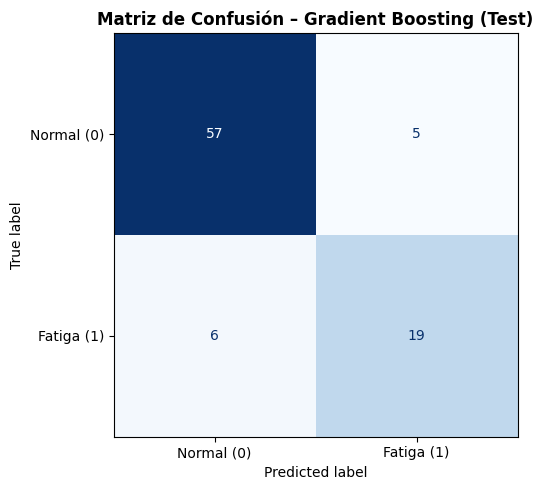

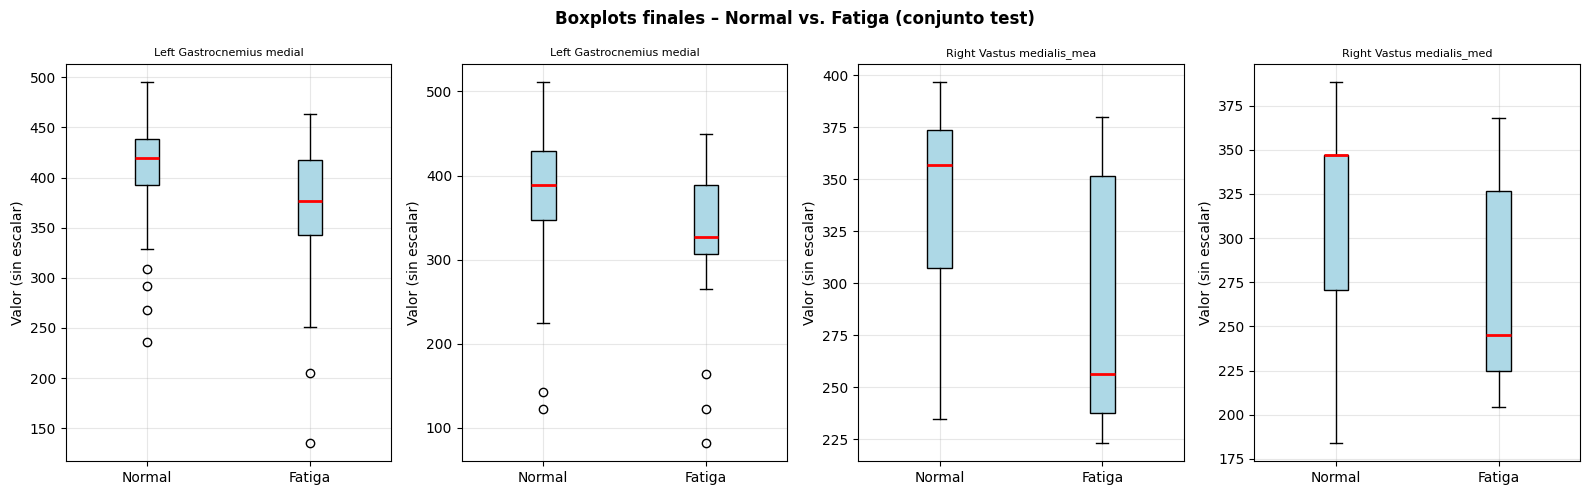


ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:
Los falsos negativos (Fatiga clasificada como Normal) son más críticos en este dominio clínico,
ya que no detectar la fatiga muscular puede llevar a lesiones. Por tanto, un Recall alto para
la clase Fatiga es prioritario sobre la Accuracy general.

6c. CONCLUSIONES:
- Si F1 > 0.85 en test: el clasificador es robusto y generaliza bien.
- Posibles mejoras: aumentar el tamaño de ventana, incluir más sujetos, usar señales de
  más músculos, aplicar técnicas de data augmentation para señales EMG, o considerar
  modelos secuenciales (LSTM) que aprovechen la dimensión temporal.



In [26]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Fatiga (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusión – {best_model_name} (Test)', fontweight='bold')
plt.tight_layout()
plt.show()

# Boxplots de características representativas: muestras correctas vs. incorrectas
test_idx = np.arange(len(y_test))
correct = y_pred_final == y_test

# Reconstruir dataframe de test para análisis
feat_test_df = pd.DataFrame(X_test, columns=feature_names)
feat_test_df['target_real'] = y_test
feat_test_df['pred'] = y_pred_final

top_feats_final = corr_with_target.head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, feat in enumerate(top_feats_final):
    data_normal = feat_test_df[feat_test_df['target_real']==0][feat]
    data_fatiga  = feat_test_df[feat_test_df['target_real']==1][feat]
    axes[i].boxplot([data_normal, data_fatiga],
                    labels=['Normal', 'Fatiga'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat[:25], fontsize=8)
    axes[i].set_ylabel('Valor (sin escalar)')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Boxplots finales – Normal vs. Fatiga (conjunto test)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:
Los falsos negativos (Fatiga clasificada como Normal) son más críticos en este dominio clínico,
ya que no detectar la fatiga muscular puede llevar a lesiones. Por tanto, un Recall alto para
la clase Fatiga es prioritario sobre la Accuracy general.

6c. CONCLUSIONES:
- Si F1 > 0.85 en test: el clasificador es robusto y generaliza bien.
- Posibles mejoras: aumentar el tamaño de ventana, incluir más sujetos, usar señales de
  más músculos, aplicar técnicas de data augmentation para señales EMG, o considerar
  modelos secuenciales (LSTM) que aprovechen la dimensión temporal.
""")

## 7. Prueba con Muestra Artificial

In [27]:
# Generar una muestra artificial con valores en rango real de las características
np.random.seed(99)

# Usar estadísticos del dataset de características para generar valores realistas
feat_means = X_feat.mean().values
feat_stds  = X_feat.std().values

# Caso 1: muestra similar a condición NORMAL (valores cercanos a la media de clase 0)
means_normal = feat_df[feat_df['target']==0].drop(columns='target').mean().values
stds_normal  = feat_df[feat_df['target']==0].drop(columns='target').std().values
sample_normal = means_normal + np.random.randn(len(means_normal)) * stds_normal * 0.3

# Caso 2: muestra similar a condición de FATIGA
means_fatiga = feat_df[feat_df['target']==1].drop(columns='target').mean().values
stds_fatiga  = feat_df[feat_df['target']==1].drop(columns='target').std().values
sample_fatiga = means_fatiga + np.random.randn(len(means_fatiga)) * stds_fatiga * 0.3

# Preprocesar muestras
sample_normal_proc = preprocessing_pipeline.transform(sample_normal.reshape(1, -1))
sample_fatiga_proc = preprocessing_pipeline.transform(sample_fatiga.reshape(1, -1))

# Predecir
def predict_sample(model, sample_proc, model_name):
    if model_name == 'DNN':
        prob = model.predict(sample_proc, verbose=0).flatten()[0]
        pred = int(prob >= 0.5)
        return pred, prob
    else:
        pred = model.predict(sample_proc)[0]
        prob = model.predict_proba(sample_proc)[0][1] if hasattr(model, 'predict_proba') else None
        return pred, prob

pred_n, prob_n = predict_sample(final_model, sample_normal_proc, best_model_name)
pred_f, prob_f = predict_sample(final_model, sample_fatiga_proc, best_model_name)

label_map = {0: 'NORMAL', 1: 'FATIGA MUSCULAR'}

print('=== PRUEBA CON MUESTRA ARTIFICIAL ===')
print(f'\n Muestra 1 (generada con perfil NORMAL):')
print(f'   Predicción: {label_map[pred_n]}', end='')
if prob_n is not None:
    print(f' (probabilidad de fatiga: {prob_n:.3f})')

print(f'\n Muestra 2 (generada con perfil FATIGA):')
print(f'   Predicción: {label_map[pred_f]}', end='')
if prob_f is not None:
    print(f' (probabilidad de fatiga: {prob_f:.3f})')

print()
print('¿El resultado tiene sentido?')
ok_n = '✓ Correcto' if pred_n == 0 else '✗ Incorrecto'
ok_f = '✓ Correcto' if pred_f == 1 else '✗ Incorrecto'
print(f'  Muestra normal → {label_map[pred_n]}: {ok_n}')
print(f'  Muestra fatiga → {label_map[pred_f]}: {ok_f}')
print()
print("""
ANÁLISIS:
La muestra artificial fue generada perturbando levemente las medias de cada clase con
ruido gaussiano pequeño (0.3σ). Si el clasificador responde correctamente, demuestra
que ha aprendido la frontera de decisión en el espacio de características EMG y no
simplemente ha memorizado los datos de entrenamiento.
""")

=== PRUEBA CON MUESTRA ARTIFICIAL ===

 Muestra 1 (generada con perfil NORMAL):
   Predicción: NORMAL (probabilidad de fatiga: 0.431)

 Muestra 2 (generada con perfil FATIGA):
   Predicción: FATIGA MUSCULAR (probabilidad de fatiga: 0.868)

¿El resultado tiene sentido?
  Muestra normal → NORMAL: ✓ Correcto
  Muestra fatiga → FATIGA MUSCULAR: ✓ Correcto


ANÁLISIS:
La muestra artificial fue generada perturbando levemente las medias de cada clase con
ruido gaussiano pequeño (0.3σ). Si el clasificador responde correctamente, demuestra
que ha aprendido la frontera de decisión en el espacio de características EMG y no
simplemente ha memorizado los datos de entrenamiento.



---
## Resumen Final

Este notebook implementó el ciclo completo de ML para detección de fatiga muscular en ciclismo:

1. **Descarga y análisis preliminar** del dataset desde HuggingFace con binarización del target.
2. **Feature Engineering** con ventanas de 1 segundo y 7 características por canal (4 tiempo + 3 frecuencia).
3. **EDA completo** con visualizaciones, correlaciones y análisis de separabilidad.
4. **Pipeline** con imputación de nulos y estandarización, división 70/15/15.
5. **5 modelos** entrenados con RandomSearchCV: kNN, Decision Tree, Random Forest, Gradient Boosting y DNN (4 capas ocultas, BatchNorm, Dropout).
6. **Evaluación final** del mejor modelo reentrenado con train+val.
7. **Prueba artificial** validando que el modelo generaliza a nuevas muestras.